# `rain_dataset_ATAC_human_1` initialization and token-length distribution

This notebook initializes `rain_dataset_ATAC_human_1` via the same Hydra-style config structure and plots the distribution of sequence lengths in tokens for the first 1000 samples.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from hydra.utils import instantiate
from omegaconf import OmegaConf
from tqdm.auto import tqdm


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "downstream_tasks").exists():
            return candidate
    raise RuntimeError("Could not find GENA_LM project root from the current working directory.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

/mnt/10tb/home/aspidova/miniconda3/envs/expression/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PosixPath('/mnt/20tb/aspeedok/GENA_LM')

In [2]:
gen_tokenizer = "AIRI-Institute/gena-lm-bert-base-t2t"

dataset_cfg = OmegaConf.create(
    {
        "_target_": "downstream_tasks.expression_prediction.expression_dataset_final.ExpressionDataset",
        "forward_intervals_path": str(
            PROJECT_ROOT
            / "downstream_tasks"
            / "expression_prediction"
            / "intervals"
            / "human.train.cre_modernbert.csv"
        ),
        "reverse_intervals_path": str(
            PROJECT_ROOT
            / "downstream_tasks"
            / "expression_prediction"
            / "intervals"
            / "human.train.reverse.cre_modernbert.csv"
        ),
        "targets_path": str(
            PROJECT_ROOT
            / "downstream_tasks"
            / "expression_prediction"
            / "datasets"
            / "data"
            / "ATACseq_Egor_Human"
            / "file_mappings_qnorm.csv"
        ),
        "genome": str(
            PROJECT_ROOT
            / "downstream_tasks"
            / "expression_prediction"
            / "datasets"
            / "data"
            / "genomes"
            / "hg38"
            / "hg38.fa"
        ),
        "bw": "bw",
        "num_before": 0,
        "token_len_for_fetch": 15,
        "transform_targets_bw": {
            "_target_": "downstream_tasks.expression_prediction.expression_dataset_final.multiplytransform",
            "coefficient": 1.5,
        },
    }
)

dataset_cfg

{'_target_': 'downstream_tasks.expression_prediction.expression_dataset_final.ExpressionDataset', 'forward_intervals_path': '/mnt/20tb/aspeedok/GENA_LM/downstream_tasks/expression_prediction/intervals/human.train.cre_modernbert.csv', 'reverse_intervals_path': '/mnt/20tb/aspeedok/GENA_LM/downstream_tasks/expression_prediction/intervals/human.train.reverse.cre_modernbert.csv', 'targets_path': '/mnt/20tb/aspeedok/GENA_LM/downstream_tasks/expression_prediction/datasets/data/ATACseq_Egor_Human/file_mappings_qnorm.csv', 'genome': '/mnt/20tb/aspeedok/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/hg38.fa', 'bw': 'bw', 'num_before': 0, 'token_len_for_fetch': 15, 'transform_targets_bw': {'_target_': 'downstream_tasks.expression_prediction.expression_dataset_final.multiplytransform', 'coefficient': 1.5}}

In [3]:
rain_dataset_ATAC_human_1 = instantiate(dataset_cfg, gen_tokenizer=gen_tokenizer)

print(rain_dataset_ATAC_human_1.describe())
print(f"Total samples: {len(rain_dataset_ATAC_human_1):,}")

Precomputing description tokens to /mnt/20tb/aspeedok/GENA_LM/downstream_tasks/expression_prediction/descriptions/file_mappings_qnorm.csv.f29b5033c5fface4.intfloat_multilingual-e5-large-instruct.1000.description.h5


Tokenizing descriptions: 100%|██████████| 170/170 [00:00<00:00, 633.71it/s]

ExpressionDataset(n_genes=92100, n_cell_types=170, n_chunks=1, bw=bw, tpm=, dataset_description=ATACseq_Egor_Human)
Total samples: 92,100


In [5]:
n_samples = min(5000, len(rain_dataset_ATAC_human_1))
token_lengths = []

for idx in tqdm(range(n_samples), desc="Collecting first 1000 token lengths"):
    sample = rain_dataset_ATAC_human_1[idx]
    token_length = int(sample["input_ids"].shape[-1])
    token_lengths.append(token_length)

length_stats = pd.Series(token_lengths, name="sequence_length_in_tokens")
length_stats.describe()

count    5000.0
mean     1024.0
std         0.0
min      1024.0
25%      1024.0
50%      1024.0
75%      1024.0
max      1024.0
Name: sequence_length_in_tokens, dtype: float64

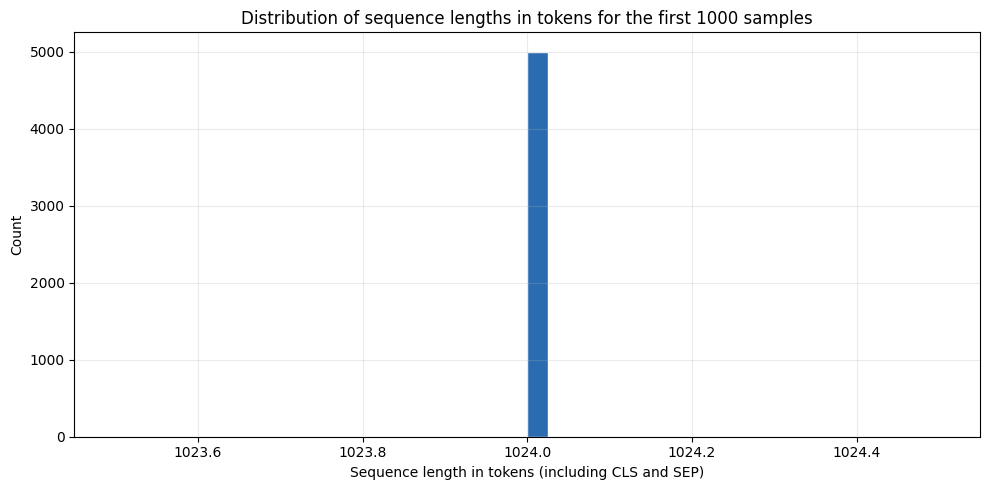

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(token_lengths, bins=40, color="#2b6cb0", edgecolor="white")
plt.title("Distribution of sequence lengths in tokens for the first 1000 samples")
plt.xlabel("Sequence length in tokens (including CLS and SEP)")
plt.ylabel("Count")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()